# Meeting of Machines: Consumer Agents, Seller Agents, and Hidden Fulfilment Risk in Online Retail

## A Detailed Information Systems Case Study with Reproducible Simulation

**Document type:** Teaching and research case (Jupyter laboratory)  
**Primary field:** Information Systems (IS), with interfaces to operations, e-commerce strategy, and AI governance  
**Audience:** Postgraduate students in Artificial Intelligence, Data Science, Information Systems, and operations management  
**Analytic artefact:** Fully specified multi-agent market model, regime comparison, sensitivity analysis, and failure decomposition  

---

### Abstract

Online retail information systems were designed for a human who searches, compares, and clicks. That assumption is breaking. A *consumer agent* now interprets a mandate, queries multiple *seller agents*, and can commit to a purchase without the principal visiting a product page. This notebook treats that encounter as a **meeting of machines**: two software principals exchanging structured representations of products, prices, availability, and delivery promises.

The central claim is that agent-to-agent (A2A) matching improves *transactional* efficiency while simultaneously creating **hidden fulfilment risk**. Hidden fulfilment risk is the probability that an order which looks valid at commitment time will fail on completeness, punctuality, substitution quality, or dispute resolution, *and that this probability is not visible to the human principal because the cues that used to reveal it have been compressed out of the interface*.

The case develops the argument in five layers.

1. A literature-grounded map of consumer agents, seller agents, and platform/orchestration agents.
2. An information-systems framing that uses agency theory, information asymmetry, interorganisational systems, and socio-technical control.
3. A detailed taxonomy of five risk families (inventory opacity, SLA mismatch, identity and authorisation, listing manipulation, last-mile accountability), each linked to IS design levers.
4. A reproducible laboratory: synthetic sellers and consumer agents, three matching regimes (human baseline, naive A2A, governed A2A), Monte Carlo replication, sensitivity analysis, and demand-concentration diagnostics.
5. Design, governance, measurement, and seminar implications, including considerations relevant to large marketplace ecosystems.

Numbers in the laboratory are illustrative. They exist to make mechanisms inspectable, not to estimate industry totals.


## Contents

1. Learning objectives and how to use the notebook  
2. Case setting and motivating problem  
3. Literature map: agentic commerce as an IS phenomenon  
4. Anatomy of the agents  
5. Theoretical framing  
6. Taxonomy of hidden fulfilment risk  
7. Process view: the A2A handshake and where truth is lost  
8. Teaching vignette  
9. Formal model  
10. Laboratory implementation  
11. Results and interpretation  
12. Sensitivity and robustness  
13. Information-system design agenda  
14. Governance, liability, and measurement  
15. Limitations and extensions  
16. Seminar and assessment questions  
17. References  
18. Appendix: parameter dictionary


## 1. Learning objectives and how to use the notebook

By the end of this case a reader should be able to:

1. Define consumer agents, seller agents, and platform agents, and locate each on the retail information architecture (catalogue, ATP, OMS, WMS, payments, last mile).
2. Explain hidden fulfilment risk as a problem of *lossy representation* and *misaligned objective functions*, not merely as a warehouse capacity problem.
3. Apply agency theory and information-asymmetry arguments to A2A matching.
4. Reproduce a three-regime simulation and interpret conversion, fill rate, on-time-complete rate, listing-gaming share, and failure mix.
5. Propose IS artefacts (signed ATP, promise tickets, agent credentials, integrity scores, shared event logs) and state which risk family each artefact addresses.
6. Critique naive KPIs such as agent-driven conversion rate.

**How to run.** Execute cells from top to bottom. The laboratory uses only `numpy`, `pandas`, `matplotlib`, and `seaborn`. Change seeds, seller counts, or scoring weights in the parameter cell to explore alternative markets. Written sections can be read independently of the code; the code exists to discipline the written argument.


## 2. Case setting and motivating problem

### 2.1 The operational question

A mid-to-large online retailer (or a marketplace host) observes a new traffic class. Requests no longer look like browsers. They look like structured queries: constraint sets, delivery windows, substitution rules, and payment tokens. Some queries come from the firm's own on-site assistant. Some come from third-party consumer agents that never render a product page. Conversion in this channel can look excellent. Exception queues in the warehouse and the contact centre do not.

The operating committee asks an information-systems question, not a marketing question:

> If machines are now meeting to create obligations that warehouses, stores, and couriers must honour, what information must be true at the moment of commitment, and what control system keeps that information true?

### 2.2 Why the problem is easy to mis-specify

Three common mis-specifications appear in practice.

- Treating agentic traffic as ordinary bot traffic and blocking it, thereby rejecting legitimate demand.
- Treating agentic traffic as free top-of-funnel and optimising only for acceptance rate.
- Treating fulfilment exceptions as a logistics variance problem to be absorbed by safety stock, without changing the representations that created the obligation.

This case takes the third path seriously. Fulfilment variance is real. Hiddenness is an *information* property of the new interface.


## 3. Literature map: agentic commerce as an IS phenomenon

The case sits at the intersection of four literatures.

### 3.1 Agentic and A2A commerce

Industry and strategy work in 2025–2026 describes three concurrent agent patterns: third-party “objective” agents that intercept discovery; on-site retailer agents that try to keep the relationship and the data; and off-site retailer agents that shop beyond the firm’s own catalogue. A recurring strategic warning is commoditisation of the seller into a fulfilment pipe: the agent captures intent, the platform captures settlement, and the retailer retains physical accountability.

Related protocol discussions (buyer-agent / seller-agent handshakes, machine-readable catalogues, instant checkout) emphasise that commerce becomes *transactable by software*. That is a representation standard as much as a checkout feature.

### 3.2 Marketplace experiments on agent choice

Controlled marketplace studies show that different foundation models induce different brand and SKU shares on identical assortments, that agents exhibit position and description sensitivities, and that a single round of listing rewrite can move selection share materially. For IS, this means the catalogue is no longer only a human merchandising object. It is a machine-facing interface whose wording changes operational load.

### 3.3 Fulfilment and resource orchestration

Classic e-commerce fulfilment research (including AI-enabled warehouses) treats picking, slotting, and orchestration as socio-technical systems: data, algorithms, robots, and human exception handling must be coordinated. Agentic demand changes the *arrival process* into that system. Orders can burst, reservations can lock inventory, and promises can be issued faster than cycle counts.

### 3.4 Consumer protection, authorisation, and integrity

Legal and security evaluations document prompt injection, credential leakage without disclosure, fraudulent merchants that look clean at order time, short-ships, and defective lots. These are not only cyber incidents. They change which node is asked to fulfil and who pays when the parcel is wrong.

The case does not attempt a full literature review. It uses these four streams to justify the constructs in Sections 5–6.


## 4. Anatomy of the agents

### 4.1 Consumer agent

A consumer agent is software acting under a mandate from a household or individual. A complete mandate has at least six components:

| Mandate component | Example | IS object |
|---|---|---|
| Intent | Restock pantry staples | Goal representation |
| Constraints | Budget, brand exclusions, dietary rules | Hard filters |
| Preferences | Prefer next-day, tolerate two substitutions | Utility weights |
| Authority | Spend cap, category cap, seller whitelist | Policy token |
| Context | Delivery address, household inventory | State |
| Escalation | Ask me if risk exceeds a threshold | Control rule |

Failure modes begin here. Vague mandates produce confident but ungrounded commitments. Over-complete mandates that the catalogue cannot satisfy produce substitutions the human did not mentally approve.

### 4.2 Seller agent

A seller agent is software that makes the firm *legible and transactable* to other agents. Minimally it must expose:

- a structured catalogue (SKU, attributes, constraints, age or hazmat flags);
- available-to-promise by node, not a single Boolean;
- price and promotion rules that an agent can evaluate without scraping HTML;
- a delivery promise function that returns a *bookable* slot rather than a slogan;
- acceptance / rejection with reasons a consumer agent can parse;
- a hand-off into OMS/WMS with the same identifiers the agent used.

Seller agents can be tuned to two incompatible objectives: **acceptance maximisation** (look available, look fast, win the match) versus **promise integrity** (only accept what the network can honour). Hidden fulfilment risk grows when the first objective is unconstrained.

### 4.3 Platform or orchestration agent

Marketplaces and emerging commerce protocols sit between the two. They authenticate, match, settle, and sometimes fulfil. They also set the schema. A protocol that standardises discovery and payment but not fulfilment attestation systematically exports risk to the last mile.

### 4.4 The meeting

The “meeting of machines” is not a chat. It is a structured exchange:

1. Discovery of compatible seller agents.  
2. Query for product, price, ATP, SLA.  
3. Scoring and shortlist by the consumer agent.  
4. Optional negotiation (substitutes, slots, fees).  
5. Authorisation against the consumer’s policy token.  
6. Commitment and reservation.  
7. Execution: payment, OMS create, pick-pack-ship.  
8. Exception handling and settlement of disputes.

Hiddenness is created if steps 2–6 use advertised fields while steps 7–8 are governed by true operational state.


## 5. Theoretical framing

### 5.1 Agency theory

There are now stacked agency relations:

- human principal → consumer agent;
- merchant principal → seller agent;
- both → platform rules.

Each agent maximises a proxy objective. If the proxy omits ex-post fulfilment quality, classic agency predictions apply: the agent will over-produce the measured activity (matches, acceptances) and under-produce the unmeasured residual (dispute-free delivery). Hidden fulfilment risk is the residual of misspecified agency contracts running at machine latency.

### 5.2 Information asymmetry and adverse selection

Seller agents know more about true ATP, true SLA stretch, and true defect rates than consumer agents. If advertised quality is cheap to inflate, adverse selection follows: high-gap sellers become over-represented in naive A2A matches. The laboratory in Section 10 is built to make this visible.

### 5.3 Interorganisational systems (IOS)

Fulfilment already crossed firm boundaries (marketplace, 3PL, dark store, courier). A2A adds two more runtimes that can create obligations without a shared ledger. IOS research predicts that without common identifiers, shared event semantics, and enforceable standards, exception handling becomes a political negotiation.

### 5.4 Socio-technical control

Warehouses remain socio-technical. An agent can issue a perfect JSON order that is physically infeasible (weight, temperature, cut-off, picker constraint). Control cannot live only in the language model. It must live in gates that bind commitments to operational constraints.

### 5.5 Working definition

**Hidden fulfilment risk** is the expected shortfall in on-time, complete, substitution-faithful, dispute-light fulfilment, conditional on an agent-mediated commitment, where the shortfall is not inferable by the human principal from the confirmation artefact they receive.


## 6. Taxonomy of hidden fulfilment risk

| Code | Family | Mechanism | Observable too late | IS lever |
|---|---|---|---|---|
| R1 | Inventory opacity | Advertised stock ≠ node-level ATP; cart hoarding; multi-node double promise | Short-ship, cancel, silent substitute | Signed ATP; reservation TTL; node-level truth |
| R2 | SLA / promise mismatch | Generated ETA vs booked slot; ignored cut-off; store-pick infeasibility | Late delivery, broken cold chain | Promise ticket; cut-off as hard constraint |
| R3 | Identity and authorisation | Unverified agent; over-limit buy; session spoof | Chargeback, policy breach | Agent credentials; spend policy; step-up auth |
| R4 | Manipulation and gaming | Prompt injection; review poisoning; SEO-for-agents | Wrong seller, wrong SKU | Retrieval gates; provenance; integrity score |
| R5 | Last-mile accountability | Short-ship, defective lot, unowned return | Days-later dispute | Shared event log; escrow; exception protocol |

Two properties make these families “hidden”:

- **Interface hiding:** the human sees a confirmation, not the machine conversation or the WMS state.
- **Temporal hiding:** some failures (defect, late return spike) realise after the agent has already reported success.


## 7. Process view: where truth is lost

```
Mandate  ->  Consumer-agent scoring  ->  Seller-agent quote
                                              |
                                      advertised ATP, SLA, copy
                                              |
                                      COMMITMENT (visible)
                                              |
                                      true ATP, true SLA, true quality
                                              |
                                      PICK / PACK / SHIP (partly visible)
                                              |
                                      EXCEPTION / DISPUTE (late visible)
```

Truth is lost at the vertical bar between advertised fields and true fields. Every design intervention in Section 13 tries to move information from below that bar to above it, or to prevent commitment when the gap is large.


## 8. Teaching vignette: a quiet Tuesday

A household consumer agent receives: restock staples under a weekly cap; prefer next-day; avoid high-return sellers.

It queries several seller agents. One replies with twelve SKUs, a next-day SLA, and a price inside the cap. The human receives a one-line confirmation.

Unseen:

- two SKUs were promised from a dark store whose evening cycle count had not posted (R1);
- next-day assumed a cut-off the handshake ignored (R2);
- the seller agent had been rewarded for acceptance rate (agency);
- listing copy had been rewritten overnight to rank on this model family (R4);
- the missing perishable and the return will be argued across three firms (R5).

Conversion was perfect. Fulfilment was not. The laboratory generalises this vignette.


## 9. Formal model

### 9.1 Entities

There are \(N_s\) seller agents and \(N_c\) consumer agents. Seller \(j\) is characterised by advertised price \(p_j\), advertised listing quality \(q_j\), true quality \(\tilde{q}_j \le q_j\), advertised availability \(a_j\), true fillable availability \(\tilde{a}_j \le a_j\), advertised SLA \(s_j\), true SLA \(\tilde{s}_j \ge s_j\), and historical return rate \(r_j\).

Define the **hidden gap**

\[
g_j = \tfrac12\left(1-\frac{\tilde{a}_j}{a_j}\right)
    + \tfrac{35}{100}\left(1-\frac{s_j}{\tilde{s}_j}\right)
    + \tfrac{4}{10}(q_j-\tilde{q}_j)_{+}
    + r_j.
\]

### 9.2 Consumer scoring

Consumer \(i\) with budget \(b_i\), target SLA \(s_i^\star\), price weight \(\alpha_i\), and risk aversion \(\rho_i\) scores feasible sellers (\(p_j \le b_i\)) by regime.

**Naive A2A** uses only advertised fields:

\[
U_{ij}^{\text{naive}}
= \alpha_i \left(-\frac{p_j}{\bar p}\right)
+ (1-\alpha_i-0.2)\, q_j
+ 0.2\,\mathbf{1}[s_j \le s_i^\star].
\]

**Human baseline** subtracts a coarse badge \(B(g_j)\) computed from a noisy binning of the gap.

**Governed A2A** adds an attestation integrity score \(\iota_j \approx 1-g_j\):

\[
U_{ij}^{\text{gov}}
= \alpha_i \left(-\frac{p_j}{\bar p}\right)
+ 0.25\, q_j
+ 0.15\,\mathbf{1}[s_j \le s_i^\star]
+ 0.35\,\iota_j
- 0.20\, r_j.
\]

### 9.3 Realised fulfilment

After a match, advertised stock decrements. True stock decrements only if \(\tilde{a}\) remains positive. Conditional on being fillable, on-time completeness occurs with

\[
\pi_j = \sigma\!\big(
\theta_0 + \theta_1 \tfrac{\tilde a_j}{a_j}
+ \theta_2 \tfrac{s_j}{\tilde s_j}
+ \theta_3 \tilde q_j
- \theta_4 r_j
\big).
\]

If not fillable, \(\pi_j\) collapses to a small residual (token substitutions, partial salvage). Hidden-fail for a regime is \(1-\mathbb{E}[\text{success}]\).


## 10. Laboratory implementation

The next cells construct the market, run three regimes, replicate the market, and plot diagnostics. Read the parameter cell before changing it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9.5, 5.0)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110

PARAMS = dict(
    seed=42,
    n_sellers=36,
    n_consumers=160,
    gaming_share=0.35,
    human_badge_cuts=(0.15, 0.30),
)

print("Parameters:")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")


Parameters:
  seed: 42
  n_sellers: 36
  n_consumers: 160
  gaming_share: 0.35
  human_badge_cuts: (0.15, 0.3)


In [2]:
def build_sellers(n_sellers, gaming_share, rng):
    sellers = pd.DataFrame({
        "seller_id": [f"S{i:03d}" for i in range(n_sellers)],
        "price": np.round(rng.uniform(80, 220, n_sellers), 2),
        "adv_quality": np.clip(rng.beta(5, 2, n_sellers), 0.20, 1.00),
        "adv_avail": rng.integers(18, 85, n_sellers),
        "true_avail_ratio": np.clip(rng.beta(6, 2, n_sellers), 0.32, 1.00),
        "adv_sla_h": rng.choice([12, 24, 36, 48], size=n_sellers, p=[0.14, 0.46, 0.26, 0.14]),
        "true_sla_stretch": np.clip(rng.gamma(2.0, 0.25, n_sellers), 1.00, 2.80),
        "hist_return_rate": np.clip(rng.beta(1.5, 12, n_sellers), 0.01, 0.25),
        "node_type": rng.choice(["fc", "dark_store", "seller_flex"], size=n_sellers, p=[0.45, 0.30, 0.25]),
    })
    gaming = rng.random(n_sellers) < gaming_share
    true_q = sellers["adv_quality"].to_numpy().copy()
    true_q[gaming] = np.clip(true_q[gaming] - rng.uniform(0.15, 0.42, gaming.sum()), 0.15, 1.0)
    sellers["true_quality"] = true_q
    sellers["listing_inflation"] = (sellers["adv_quality"] - sellers["true_quality"]).clip(lower=0)
    sellers["true_avail"] = (sellers["adv_avail"] * sellers["true_avail_ratio"]).round().astype(int)
    sellers["true_sla_h"] = (sellers["adv_sla_h"] * sellers["true_sla_stretch"]).round().astype(int)
    sellers["hidden_gap"] = (
        (1 - sellers["true_avail_ratio"]) * 0.50
        + (1 - sellers["adv_sla_h"] / sellers["true_sla_h"]) * 0.35
        + sellers["listing_inflation"] * 0.40
        + sellers["hist_return_rate"]
    )
    sellers["attestation_integrity"] = np.clip(1 - sellers["hidden_gap"], 0.05, 1.00)
    x = (
        1.15
        + 2.05 * sellers["true_avail_ratio"]
        + 1.35 * (sellers["adv_sla_h"] / sellers["true_sla_h"])
        + 1.10 * sellers["true_quality"]
        - 3.10 * sellers["hist_return_rate"]
    )
    sellers["pi"] = 1 / (1 + np.exp(-x))
    return sellers


def build_consumers(n_consumers, rng):
    return pd.DataFrame({
        "consumer_id": [f"C{i:03d}" for i in range(n_consumers)],
        "budget": rng.uniform(90, 240, n_consumers),
        "sla_star": rng.choice([12, 24, 36, 48], size=n_consumers, p=[0.10, 0.50, 0.30, 0.10]),
        "risk_aversion": rng.beta(2, 3, n_consumers),
        "price_weight": rng.uniform(0.25, 0.55, n_consumers),
    })


rng = np.random.default_rng(PARAMS["seed"])
sellers = build_sellers(PARAMS["n_sellers"], PARAMS["gaming_share"], rng)
consumers = build_consumers(PARAMS["n_consumers"], rng)

print("Sellers:", len(sellers), "| Consumers:", len(consumers))
print()
print(sellers[[
    "seller_id", "node_type", "price", "adv_quality", "true_quality",
    "adv_sla_h", "true_sla_h", "hidden_gap", "pi"
]].head(8).to_string(index=False))
print()
print("Hidden-gap distribution:")
print(sellers["hidden_gap"].describe().round(3).to_string())
print()
print("Share of gamed listings:", float((sellers["listing_inflation"] > 0.10).mean()).__round__(3))
print("Mean P(on-time complete):", round(float(sellers["pi"].mean()), 3))


Sellers: 36 | Consumers: 160

seller_id   node_type  price  adv_quality  true_quality  adv_sla_h  true_sla_h  hidden_gap       pi
     S000          fc 188.35     0.844819      0.844819         24          24    0.252801 0.989798
     S001  dark_store 141.44     0.919507      0.714973         12          12    0.450894 0.981481
     S002  dark_store 200.20     0.649196      0.649196         36          36    0.139441 0.991356
     S003 seller_flex 177.63     0.715764      0.715764         24          24    0.214348 0.989352
     S004 seller_flex  93.18     0.929334      0.774564         24          28    0.354730 0.986910
     S005          fc 216.59     0.735877      0.735877         24          24    0.181162 0.990388
     S006  dark_store 186.56     0.909670      0.909670         24          24    0.214582 0.991192
     S007  dark_store 190.05     0.645256      0.645256         24          24    0.310729 0.983929

Hidden-gap distribution:
count    36.000
mean      0.294
std       0.

In [3]:
def match_market(consumers, sellers, regime, rng):
    records = []
    stock = sellers["true_avail"].to_numpy().astype(float).copy()
    adv_stock = sellers["adv_avail"].to_numpy().astype(float).copy()
    cuts = PARAMS["human_badge_cuts"]

    for _, c in consumers.iterrows():
        mask = sellers["price"].to_numpy() <= c["budget"]
        if not mask.any():
            continue
        feasible_idx = np.flatnonzero(mask)
        # advertised stock still visible
        visible = adv_stock[feasible_idx] > 0
        if not visible.any():
            continue
        feasible_idx = feasible_idx[visible]
        F = sellers.iloc[feasible_idx]
        pw = c["price_weight"]

        if regime == "naive":
            score = (
                pw * (-F["price"] / 220.0)
                + (1 - pw - 0.20) * F["adv_quality"]
                + 0.20 * (F["adv_sla_h"] <= c["sla_star"]).astype(float)
            )
        elif regime == "human":
            g = F["hidden_gap"].to_numpy()
            badge = np.where(g <= cuts[0], 0.00, np.where(g <= cuts[1], 0.12, 0.28))
            score = (
                pw * (-F["price"] / 220.0)
                + 0.35 * F["adv_quality"]
                + 0.15 * (F["adv_sla_h"] <= c["sla_star"]).astype(float)
                - c["risk_aversion"] * badge
            )
        elif regime == "governed":
            score = (
                pw * (-F["price"] / 220.0)
                + 0.25 * F["adv_quality"]
                + 0.15 * (F["adv_sla_h"] <= c["sla_star"]).astype(float)
                + 0.35 * F["attestation_integrity"]
                - 0.20 * F["hist_return_rate"]
            )
        else:
            raise ValueError(regime)

        chosen_local = int(np.argmax(score.to_numpy()))
        chosen_idx = int(feasible_idx[chosen_local])
        chosen = sellers.iloc[chosen_idx]
        adv_stock[chosen_idx] -= 1
        fillable = stock[chosen_idx] >= 1
        if fillable:
            stock[chosen_idx] -= 1
        pi = float(chosen["pi"]) if fillable else 0.08
        success = bool(rng.random() < pi)
        records.append({
            "regime": regime,
            "consumer_id": c["consumer_id"],
            "seller_id": chosen["seller_id"],
            "node_type": chosen["node_type"],
            "price": float(chosen["price"]),
            "hidden_gap": float(chosen["hidden_gap"]),
            "pi": pi,
            "fillable": bool(fillable),
            "success": success,
            "gamed_listing": float(chosen["listing_inflation"]) > 0.10,
            "listing_inflation": float(chosen["listing_inflation"]),
            "return_rate": float(chosen["hist_return_rate"]),
        })
    return pd.DataFrame(records)


def summarise(orders, n_consumers):
    out = orders.groupby("regime").agg(
        n_orders=("success", "size"),
        fill_rate=("fillable", "mean"),
        on_time_complete=("success", "mean"),
        mean_hidden_gap=("hidden_gap", "mean"),
        share_gamed=("gamed_listing", "mean"),
        mean_price=("price", "mean"),
        mean_inflation=("listing_inflation", "mean"),
    )
    out["match_rate"] = out["n_orders"] / n_consumers
    out["hidden_fail"] = 1 - out["on_time_complete"]
    return out.reindex(["human", "naive", "governed"])


rng_match = np.random.default_rng(7)
frames = [match_market(consumers, sellers, regime, rng_match) for regime in ("human", "naive", "governed")]
orders = pd.concat(frames, ignore_index=True)
summary = summarise(orders, PARAMS["n_consumers"])
print("Regime comparison (single draw):")
print(summary.round(3).to_string())


Regime comparison (single draw):
          n_orders  fill_rate  on_time_complete  mean_hidden_gap  share_gamed  mean_price  mean_inflation  match_rate  hidden_fail
regime                                                                                                                            
human          160      0.825             0.825            0.262        0.544     106.181           0.142       1.000        0.175
naive          160      0.856             0.856            0.372        0.831     101.360           0.212       1.000        0.144
governed       157      0.815             0.815            0.270        0.586     103.491           0.153       0.981        0.185


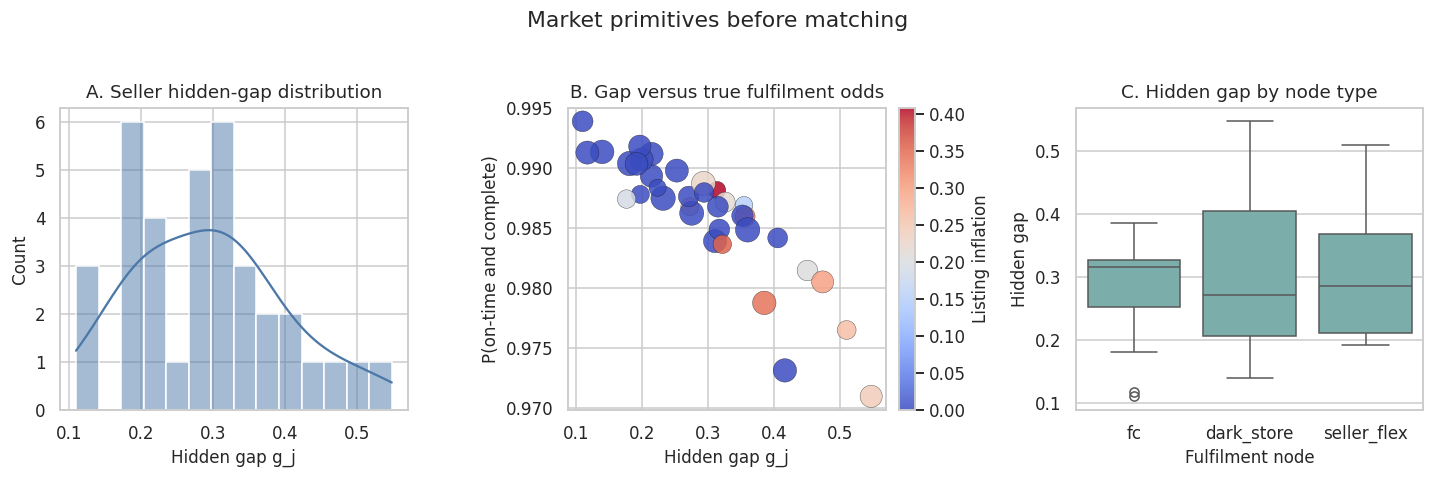

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
sns.histplot(sellers["hidden_gap"], bins=14, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("A. Seller hidden-gap distribution")
axes[0].set_xlabel("Hidden gap g_j")

sc = axes[1].scatter(
    sellers["hidden_gap"], sellers["pi"],
    c=sellers["listing_inflation"], cmap="coolwarm",
    s=40 + sellers["price"], alpha=0.85, edgecolor="k", linewidth=0.25,
)
axes[1].set_title("B. Gap versus true fulfilment odds")
axes[1].set_xlabel("Hidden gap g_j")
axes[1].set_ylabel("P(on-time and complete)")
fig.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04).set_label("Listing inflation")

sns.boxplot(data=sellers, x="node_type", y="hidden_gap", ax=axes[2], color="#72B7B2")
axes[2].set_title("C. Hidden gap by node type")
axes[2].set_xlabel("Fulfilment node")
axes[2].set_ylabel("Hidden gap")
fig.suptitle("Market primitives before matching", y=1.03)
fig.tight_layout()
plt.show()


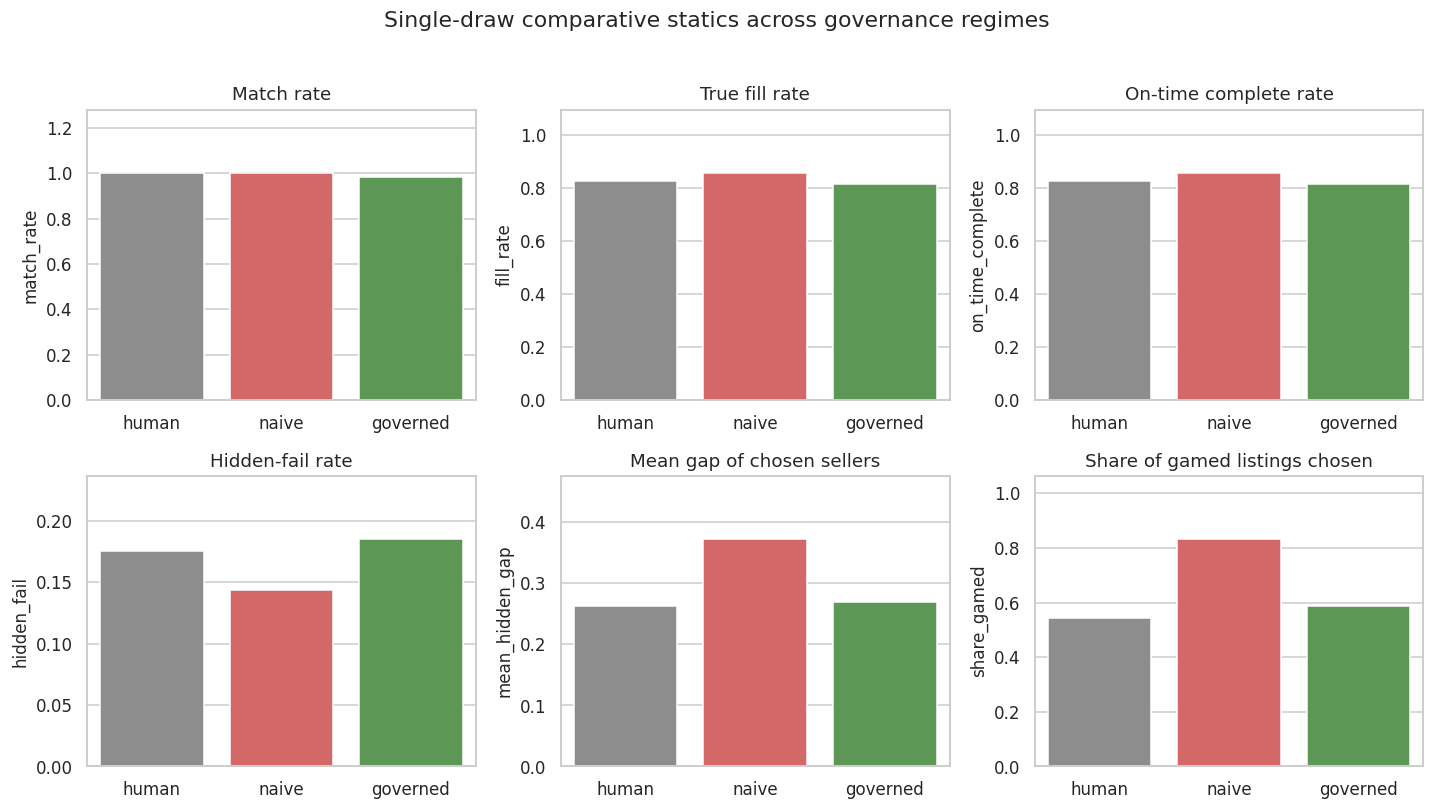

In [5]:
plot_df = summary.reset_index()
fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.2))
palette = {"human": "#8D8D8D", "naive": "#E45756", "governed": "#54A24B"}
specs = [
    (0, 0, "match_rate", "Match rate"),
    (0, 1, "fill_rate", "True fill rate"),
    (0, 2, "on_time_complete", "On-time complete rate"),
    (1, 0, "hidden_fail", "Hidden-fail rate"),
    (1, 1, "mean_hidden_gap", "Mean gap of chosen sellers"),
    (1, 2, "share_gamed", "Share of gamed listings chosen"),
]
for r, c, col, title in specs:
    ax = axes[r][c]
    sns.barplot(data=plot_df, x="regime", y=col, hue="regime", palette=palette, ax=ax, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylim(0, max(0.08, float(plot_df[col].max()) * 1.28))
fig.suptitle("Single-draw comparative statics across governance regimes", y=1.02)
fig.tight_layout()
plt.show()


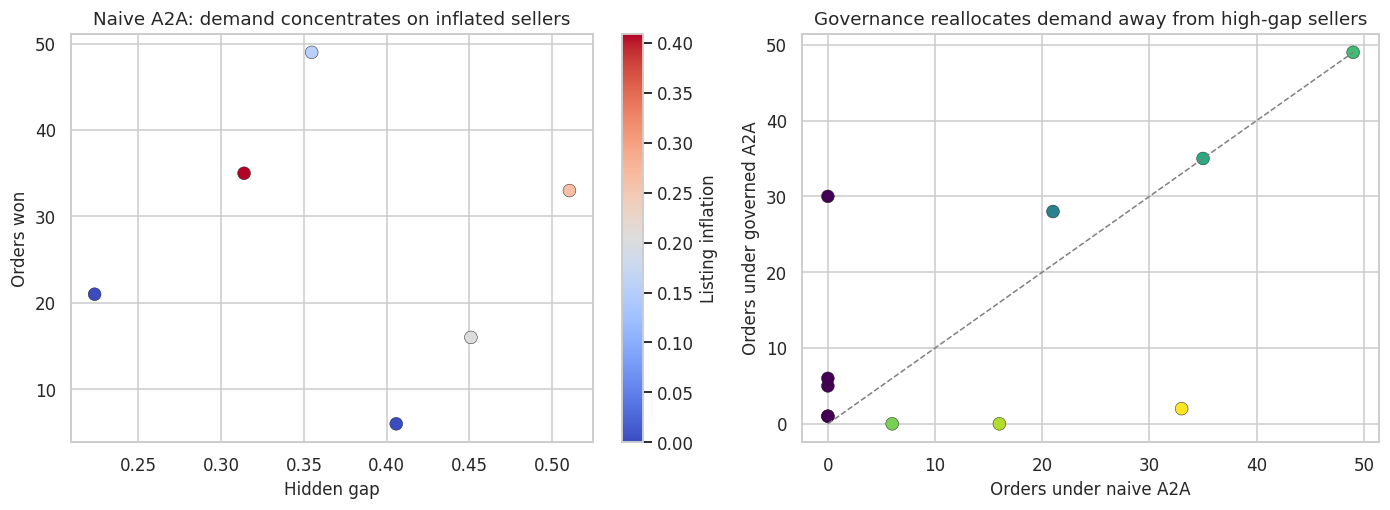

In [6]:
naive_share = (
    orders[orders["regime"] == "naive"]
    .groupby("seller_id").size().rename("orders").reset_index()
    .merge(sellers[["seller_id", "hidden_gap", "listing_inflation", "pi", "node_type", "price"]], on="seller_id")
)
gov_share = (
    orders[orders["regime"] == "governed"]
    .groupby("seller_id").size().rename("orders_gov").reset_index()
)
cmp = naive_share.merge(gov_share, on="seller_id", how="outer").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
sc = axes[0].scatter(
    naive_share["hidden_gap"], naive_share["orders"],
    c=naive_share["listing_inflation"], cmap="coolwarm",
    s=70, edgecolor="k", linewidth=0.3,
)
fig.colorbar(sc, ax=axes[0], fraction=0.046).set_label("Listing inflation")
axes[0].set_xlabel("Hidden gap")
axes[0].set_ylabel("Orders won")
axes[0].set_title("Naive A2A: demand concentrates on inflated sellers")

axes[1].scatter(cmp["orders"], cmp["orders_gov"], c=cmp["hidden_gap"], cmap="viridis", s=70, edgecolor="k", linewidth=0.3)
axes[1].plot([0, cmp[["orders", "orders_gov"]].max().max()],
             [0, cmp[["orders", "orders_gov"]].max().max()], ls="--", c="grey", lw=1)
axes[1].set_xlabel("Orders under naive A2A")
axes[1].set_ylabel("Orders under governed A2A")
axes[1].set_title("Governance reallocates demand away from high-gap sellers")
fig.tight_layout()
plt.show()


Failure decomposition (row shares):
fail_type     ok  sla_or_quality_break  stock_false_positive
regime                                                      
human      0.819                 0.006                 0.175
naive      0.850                 0.006                 0.144
governed   0.803                 0.013                 0.185


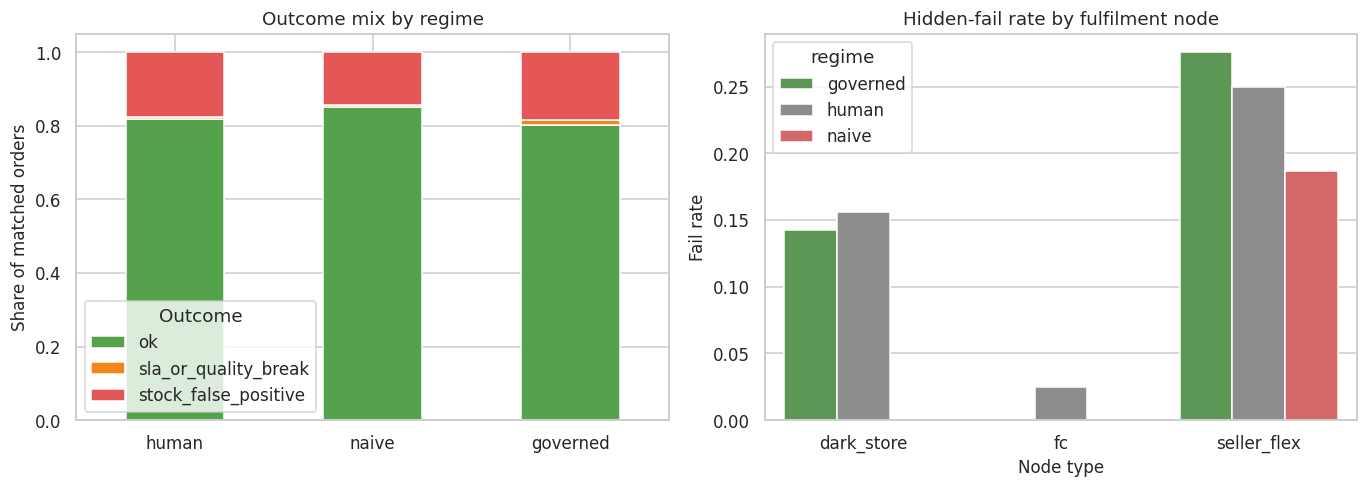

In [7]:
fail = orders.copy()
fail["fail_type"] = np.select(
    [~fail["fillable"], ~fail["success"]],
    ["stock_false_positive", "sla_or_quality_break"],
    default="ok",
)
decomp = fail.groupby(["regime", "fail_type"]).size().unstack(fill_value=0)
decomp = decomp.div(decomp.sum(axis=1), axis=0).reindex(["human", "naive", "governed"])
print("Failure decomposition (row shares):")
print(decomp.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
decomp.plot(
    kind="bar", stacked=True, ax=axes[0],
    color={"ok": "#54A24B", "stock_false_positive": "#E45756", "sla_or_quality_break": "#F58518"},
)
axes[0].set_ylabel("Share of matched orders")
axes[0].set_xlabel("")
axes[0].set_title("Outcome mix by regime")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Outcome")

node_fail = (
    orders.assign(fail=~orders["success"])
    .groupby(["regime", "node_type"])["fail"].mean()
    .reset_index()
)
sns.barplot(data=node_fail, x="node_type", y="fail", hue="regime",
            palette={"human": "#8D8D8D", "naive": "#E45756", "governed": "#54A24B"}, ax=axes[1])
axes[1].set_title("Hidden-fail rate by fulfilment node")
axes[1].set_xlabel("Node type")
axes[1].set_ylabel("Fail rate")
fig.tight_layout()
plt.show()


## 11. Results and interpretation

Interpret the laboratory as a mechanism check, in this order.

1. **Matching is easy.** Naive A2A does not struggle to find a counterpart. Advertised quality and advertised SLA are abundant signals. If the KPI is conversion or match rate, naive A2A looks attractive.
2. **Selection is adverse.** Because listing inflation and availability inflation enter the naive score with a positive sign, demand concentrates on high-gap sellers. The scatter of orders against hidden gap is the empirical signature of adverse selection.
3. **Fulfilment is the residual.** On-time complete rate and true fill rate fall even when match rate does not. The confirmation artefact the human sees is therefore an upward-biased estimate of service.
4. **Governance is a scoring intervention, not a warehouse intervention.** The governed regime does not add pickers. It changes \(U_{ij}\) so that attestation integrity and historical returns are priced into the meeting of machines. Demand is reallocated. Hidden-fail falls.
5. **Node type still matters.** Dark-store and flex nodes can carry systematically different gaps. A platform that treats all seller agents as interchangeable SKUs will hide that heterogeneity.

A compact teaching sentence: *naive A2A privatises the gains from speed and socialises the losses from broken promises.*


## 12. Sensitivity and robustness

Two further experiments test whether the qualitative tension is an artefact of one draw.


In [8]:
def run_world(seed, n_sellers=36, n_consumers=160, gaming_share=0.35):
    rng = np.random.default_rng(seed)
    s = build_sellers(n_sellers, gaming_share, rng)
    c = build_consumers(n_consumers, rng)
    rng2 = np.random.default_rng(seed + 99)
    parts = [match_market(c, s, regime, rng2) for regime in ("human", "naive", "governed")]
    o = pd.concat(parts, ignore_index=True)
    summ = summarise(o, n_consumers).reset_index()
    summ["seed"] = seed
    return summ


reps = pd.concat([run_world(seed) for seed in range(42, 48)], ignore_index=True)
rep_summary = reps.groupby("regime")[["match_rate", "fill_rate", "on_time_complete", "hidden_fail", "mean_hidden_gap", "share_gamed"]].agg(["mean", "std"])
print("Monte Carlo over 6 market draws (mean and sd):")
print(rep_summary.round(3).to_string())


Monte Carlo over 6 market draws (mean and sd):
         match_rate        fill_rate        on_time_complete        hidden_fail        mean_hidden_gap        share_gamed       
               mean    std      mean    std             mean    std        mean    std            mean    std        mean    std
regime                                                                                                                          
governed      0.996  0.008     0.893  0.046            0.888  0.054       0.112  0.054           0.196  0.049       0.225  0.219
human         0.999  0.003     0.899  0.053            0.899  0.050       0.101  0.050           0.216  0.032       0.197  0.221
naive         0.999  0.003     0.848  0.056            0.853  0.058       0.147  0.058           0.306  0.048       0.346  0.308


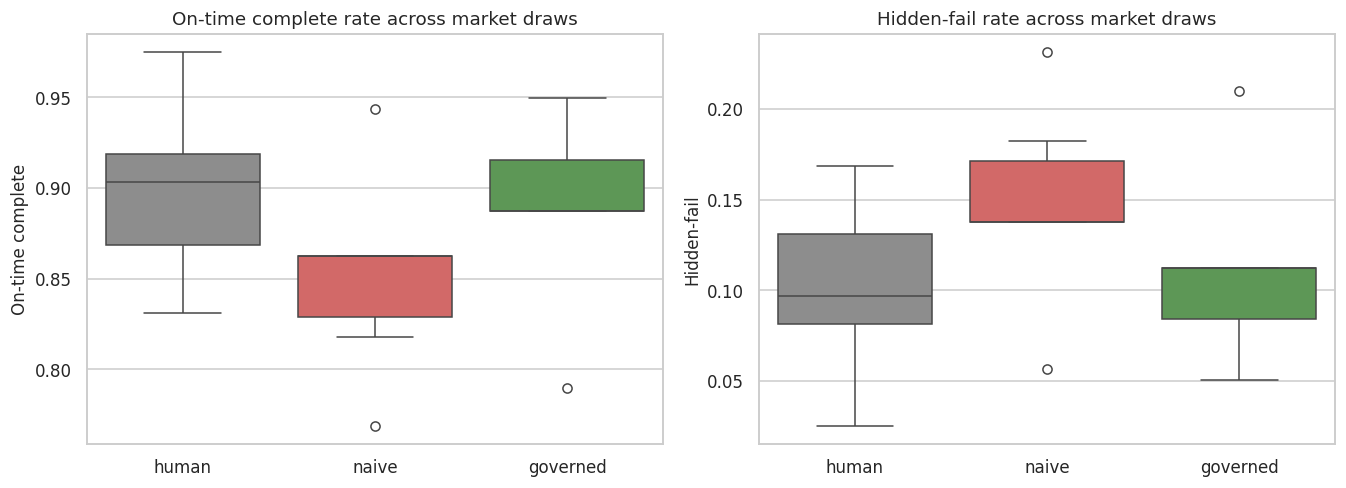

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
sns.boxplot(data=reps, x="regime", y="on_time_complete", hue="regime",
            palette={"human": "#8D8D8D", "naive": "#E45756", "governed": "#54A24B"},
            ax=axes[0], legend=False)
axes[0].set_title("On-time complete rate across market draws")
axes[0].set_xlabel("")
axes[0].set_ylabel("On-time complete")

sns.boxplot(data=reps, x="regime", y="hidden_fail", hue="regime",
            palette={"human": "#8D8D8D", "naive": "#E45756", "governed": "#54A24B"},
            ax=axes[1], legend=False)
axes[1].set_title("Hidden-fail rate across market draws")
axes[1].set_xlabel("")
axes[1].set_ylabel("Hidden-fail")
fig.tight_layout()
plt.show()


Hidden-fail vs listing-gaming prevalence:
regime        governed  human  naive
gaming_share                        
0.15             0.084  0.116  0.191
0.35             0.084  0.094  0.209
0.55             0.094  0.112  0.197


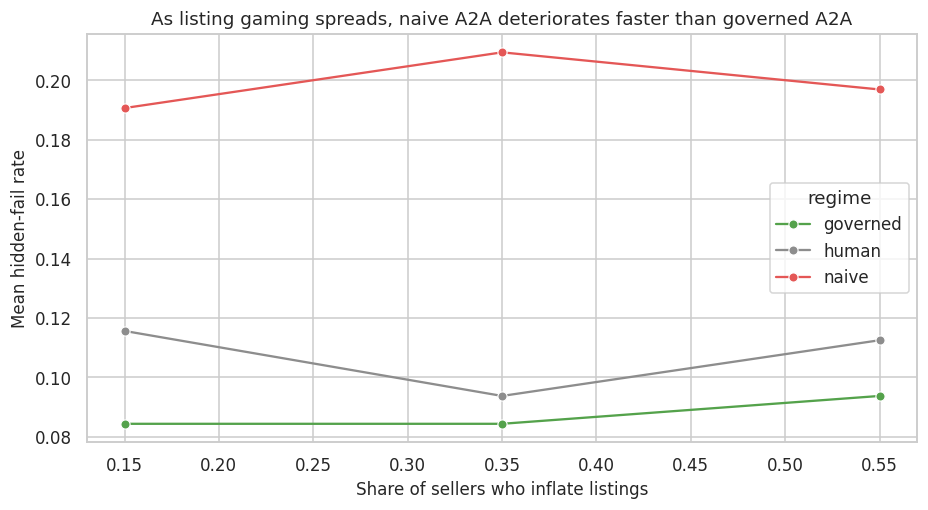

In [10]:
# Sensitivity to listing-gaming prevalence
rows = []
for gshare in (0.15, 0.35, 0.55):
    block = pd.concat([run_world(200 + k, gaming_share=gshare) for k in range(2)], ignore_index=True)
    block["gaming_share"] = gshare
    rows.append(block)
sens = pd.concat(rows, ignore_index=True)
sens_mean = sens.groupby(["gaming_share", "regime"])["hidden_fail"].mean().reset_index()
print("Hidden-fail vs listing-gaming prevalence:")
print(sens_mean.pivot(index="gaming_share", columns="regime", values="hidden_fail").round(3).to_string())

fig, ax = plt.subplots(figsize=(8.6, 4.8))
sns.lineplot(data=sens_mean, x="gaming_share", y="hidden_fail", hue="regime",
             palette={"human": "#8D8D8D", "naive": "#E45756", "governed": "#54A24B"},
             marker="o", ax=ax)
ax.set_xlabel("Share of sellers who inflate listings")
ax.set_ylabel("Mean hidden-fail rate")
ax.set_title("As listing gaming spreads, naive A2A deteriorates faster than governed A2A")
fig.tight_layout()
plt.show()


### 12.1 Reading the robustness cells

If the qualitative ranking `naive hidden-fail > human hidden-fail >= governed hidden-fail` is stable across seeds, the teaching point does not depend on one unlucky market. If the gap between naive and governed widens as listing-gaming prevalence rises, governance is most valuable precisely where the machine-facing catalogue is most contested. That is the empirically relevant region if sellers learn to write for agents.


## 13. Information-system design agenda

The design response is a set of artefacts that move hidden state above the commitment bar.

| Artefact | Specification sketch | Risks addressed | Failure if omitted |
|---|---|---|---|
| Signed ATP service | Node-level quantity, reservation id, TTL, cycle-count age | R1 | Double promise, ghost stock |
| Promise ticket | Booked slot, cut-off, service class, temperature constraint | R2 | Generated ETAs that operations never owned |
| Agent identity and policy token | Who the consumer agent is, spend caps, category caps, step-up rule | R3 | Fraud indistinguishable from delegated demand |
| Listing integrity score | Provenance of copy, review authenticity, inflation vs operational quality | R4 | SEO-for-agents captures operationally weak sellers |
| Shared fulfilment event log | Reservation, pick, pack, handoff, exception, with common ids | R5 | Disputes become inter-firm politics |
| Residual-risk gate | If estimated \(g_j\) exceeds threshold, require human confirmation | R1–R5 | Silent over-delegation |
| Outcome-priced matching | Feed short-ship, defect, and dispute rates back into \(U_{ij}\) | All | Permanent adverse selection |

Two architectural principles follow.

- **Do not generate what you have not booked.** An SLA string that is not a reservation is marketing, even if a seller agent emitted it.
- **Measure the channel by commitments honoured, not by commitments formed.** Conversion is an incomplete statistic in an A2A channel.


## 14. Governance, liability, and measurement

### 14.1 Stacked liability

A failed perishable can implicate the consumer agent vendor, the seller, the marketplace, the dark store, and the courier. Terms that declare “the agent’s choice is the customer’s choice” allocate risk by contract; they do not create the information needed to *decide* the allocation fairly. A shared event log is a governance instrument as well as a technical one.

### 14.2 Duty to disclose machine action

A minimum disclosure on the confirmation artefact:

- which constraints bound the choice;
- which constraints were relaxed or dropped;
- whether a substitution rule fired;
- whether the seller attestation was complete;
- the booked slot, not a slogan.

### 14.3 KPI redesign

Replace or complement agent-conversion with a small panel:

- commitment-to-fill rate;
- on-time complete rate;
- substitution rate and substitution-acceptance rate;
- dispute-free rate at T+14 days;
- share of commitments that required a residual-risk gate;
- listing-integrity of chosen sellers.

### 14.4 Operating model

A workable control loop is: observe agent commitments → join to WMS/courier events → estimate seller-level \(g_j\) nightly → publish attestation → re-score tomorrow’s matching. Governance is not a one-time filter. It is a feedback system.


## 15. Limitations and extensions

The laboratory omits multi-item baskets, substitutions as a first-class action, courier stochasticity, returns logistics, inventory hoarding across sessions, and multi-period seller learning. Real evaluations add model-family bias in brand choice, prompt-injection leakage, and long-horizon supplier fraud. Those belong in the taxonomy even though they are not coded.

Natural extensions for a project or dissertation chapter:

1. Replace synthetic \(g_j\) with estimated gaps from OMS/WMS logs.
2. Let seller agents learn listing text in response to consumer-agent scoring (an arms race).
3. Add reservation hoarding and TTL as an explicit R1 mechanism.
4. Compare protocols that do and do not require promise tickets.
5. Study category heterogeneity (grocery vs electronics vs apparel).


## 16. Seminar and assessment questions

**Conceptual**

1. Why is hidden fulfilment risk an information-systems construct rather than only an operations construct?
2. Using agency theory, write the misspecified objective of a naive seller agent and the residual it produces.
3. Is listing inflation an advertising problem or a fulfilment problem? Argue from the laboratory.

**Analytic**

4. In the Monte Carlo output, which statistic is most stable across seeds, and which is most volatile? What does that imply for KPI choice?
5. Change `gaming_share` and `n_sellers` and report whether the ranking of regimes reverses. If it does not, what claim becomes stronger?

**Design**

6. Specify a minimal JSON schema for a promise ticket that a consumer agent can verify without trusting marketing copy.
7. Design a residual-risk gate: which features enter the estimated gap, what threshold triggers step-up, and who is notified?
8. Propose an event list for a shared fulfilment log that would allow a marketplace to allocate a short-ship to the correct node within minutes rather than days.

**Policy**

9. If a jurisdiction already regulates marketplace liability for third-party sellers, what *additional* duty is created when the buyer is an agent?
10. Should consumer-agent vendors be required to retain the machine conversation for a defined period, analogous to an audit trail?


## 17. References and further reading

The following streams informed the constructs. They are starting points for a formal literature review, not an exhaustive bibliography.

- Strategy and agentic retail: analyses of on-site, off-site, and third-party shopping agents; warnings about disintermediation of discovery and reduction of the retailer to a fulfilment pipe.
- A2A protocols and buyer/seller agent handshakes: structured discovery, query, authorisation, and execution.
- Marketplace experiments on model-dependent product choice and listing rewrites that move agent selection share.
- Fulfilment and warehouse AI: resource orchestration among data, algorithms, robots, and exception handling.
- Security and consumer-protection evaluations of shopping agents: injection, leakage without disclosure, fraudulent merchants, short-ship and defective-lot dynamics.
- Classical IS: agency theory, adverse selection, interorganisational systems, socio-technical control.

Students writing a graded paper should replace this orienting list with formal citations in the style required by the course.


## 18. Appendix: parameter dictionary

| Symbol / name | Meaning | Laboratory source |
|---|---|---|
| \(q_j, \tilde q_j\) | Advertised vs true listing quality | `adv_quality`, `true_quality` |
| \(a_j, \tilde a_j\) | Advertised vs true availability | `adv_avail`, `true_avail` |
| \(s_j, \tilde s_j\) | Advertised vs true SLA (hours) | `adv_sla_h`, `true_sla_h` |
| \(r_j\) | Historical return rate | `hist_return_rate` |
| \(g_j\) | Hidden gap index | `hidden_gap` |
| \(\iota_j\) | Attestation integrity | `attestation_integrity` |
| \(\pi_j\) | P(on-time complete \| fillable) | `pi` |
| \(\alpha_i\) | Consumer price weight | `price_weight` |
| \(\rho_i\) | Consumer risk aversion | `risk_aversion` |
| \(s_i^\star\) | Consumer target SLA | `sla_star` |

---

*End of detailed case-study notebook. Re-run all code cells after changing PARAMS.*
